In [ ]:
dat <- sim(b_xy = -0.5, b_uy = -0.2, b_ux = 1, b_prs=1, h2=0.7, r2_env_height=0.15, r2_prs=0.4, n=100000)[[2]]
str(dat)

tibble [100,000 × 9] (S3: tbl_df/tbl/data.frame)
 $ prs_explained  : num [1:100000] -0.4 0.114 0.213 -0.449 0.138 ...
 $ prs_unexplained: num [1:100000] -0.21 -0.692 -0.491 0.825 0.526 ...
 $ prs            : num [1:100000] -0.61 -0.577 -0.277 0.377 0.665 ...
 $ u              : num [1:100000] -0.106 0.406 0.151 -0.251 0.682 ...
 $ ex             : num [1:100000] 0.518 -0.422 -0.401 -0.494 -0.104 ...
 $ x              : num [1:100000] -0.199 -0.593 -0.527 -0.369 1.242 ...
 $ residual_x     : num [1:100000] 0.2013 -0.7078 -0.74 0.0798 1.104 ...
 $ ey             : num [1:100000] -0.955 -0.132 0.382 -1.381 -0.833 ...
 $ y              : num [1:100000] -0.8345 0.0837 0.6148 -1.1465 -1.5905 ...


In [ ]:
gx_to_gp <- function(liability, varexp, prevalence) {
	x_prime <- qnorm(prevalence, 0, 1, lower.tail=FALSE)
	p <- pnorm(x_prime, mean=liability, sd = sqrt(1 - varexp), lower.tail=FALSE)
	return(p)
}

generate_binary_outcome <- function(liability, varexp, prevalence) {
    cc <- rbinom(length(liability), 1, gx_to_gp(liability, varexp, prevalence))
    return(cc)
}

binary_2sls <- function(x, y, prs) {
    mod <- summary(glm(y ~ prs, family="binomial"))
    bgy <- mod$coefficients[2, 1]
    se_bgy <- mod$coefficients[2, 2]

    mod <- summary(lm(x ~ prs))
    bgx <- mod$coefficients[2, 1]
    se_bgx <- mod$coefficients[2, 2]
    beta_xy <- bgy / bgx
    se_beta_xy <- sqrt((se_bgy / bgx)^2 + (bgy * se_bgx / bgx^2)^2)
    return(list(beta_xy = beta_xy, se_beta_xy = se_beta_xy))
}

continuous_2sls <- function(x, y, prs) {
    mod <- summary(lm(y ~ prs))
    bgy <- mod$coefficients[2, 1]
    se_bgy <- mod$coefficients[2, 2]

    mod <- summary(lm(x ~ prs))
    bgx <- mod$coefficients[2, 1]
    se_bgx <- mod$coefficients[2, 2]
    beta_xy <- bgy / bgx
    se_beta_xy <- sqrt((se_bgy / bgx)^2 + (bgy * se_bgx / bgx^2)^2)
    return(list(beta_xy = beta_xy, se_beta_xy = se_beta_xy))
}

dat$cc <- generate_binary_outcome(dat$y, varexp = 0.2, prevalence = 0.1)

continuous_2sls(dat$x, dat$y, dat$prs_explained)
binary_2sls(dat$x, dat$cc, dat$prs_explained)

$beta_xy
[1] -0.497851

$se_beta_xy
[1] 0.007073766

$beta_xy
[1] -0.6264097

$se_beta_xy
[1] 0.01601543

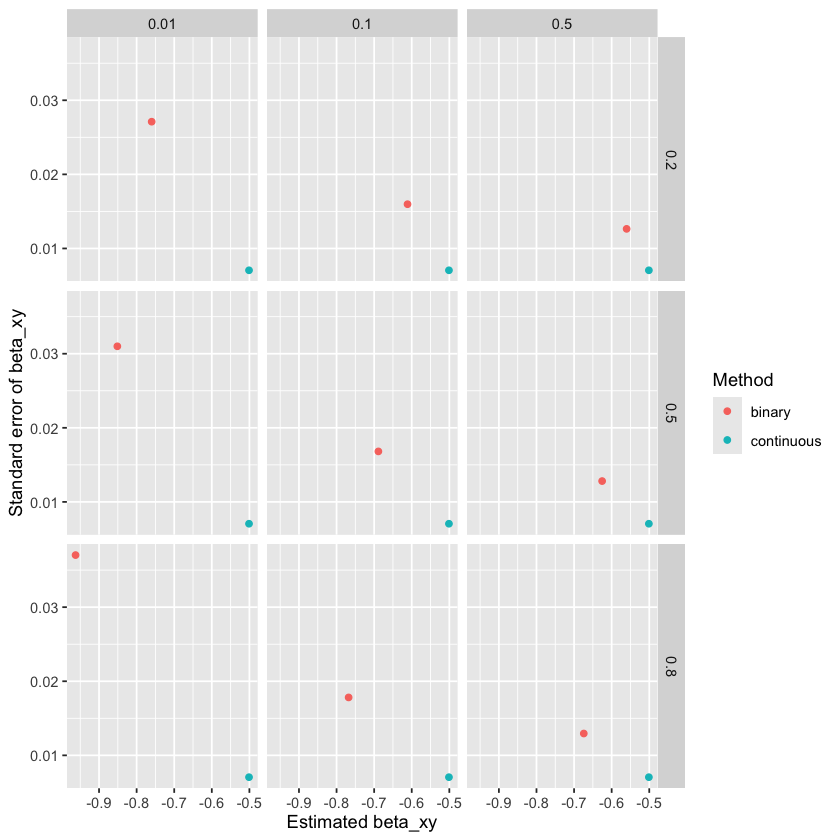

In [ ]:
param <- expand.grid(
    varexp = c(0.2, 0.5, 0.8),
    prevalence = c(0.01, 0.1, 0.5)
)

binary_res <- lapply(1:nrow(param), \(i) {
    varexp <- param[i,]$varexp
    prevalence <- param[i,]$prevalence
    dat$cc <- generate_binary_outcome(dat$y, varexp = varexp, prevalence = prevalence)
    res_continuous <- continuous_2sls(dat$x, dat$y, dat$prs_explained)
    res_binary <- binary_2sls(dat$x, dat$cc, dat$prs_explained)
    tibble(
        varexp = varexp,
        prevalence = prevalence,
        method = c("binary", "continuous"),
        beta_xy = c(res_binary$beta_xy, res_continuous$beta_xy),
        se_beta_xy = c(res_binary$se_beta_xy, res_continuous$se_beta_xy)
    )
}) %>% bind_rows()

ggplot(binary_res, aes(x = beta_xy, y = se_beta_xy, color = method)) +
    geom_point() +
    facet_grid(varexp ~ prevalence) +
    labs(x = "Estimated beta_xy", y = "Standard error of beta_xy", color = "Method")

In [ ]:
estimate_beta_cy(
    height = dat$x,
    prs = dat$prs_explained,
    outcome = dat$cc,
    var_c = 0.15,
    h2 = 0.7,
    n_boot = 100
)

estimate_beta_cy(
    height = dat$x,
    prs = dat$prs_explained,
    outcome = dat$y,
    var_c = 0.15,
    h2 = 0.7,
    n_boot = 100
)


Binary outcome detected (prevalence = 0.189)
Liability scale transformation factor = 0.2705


$beta_xy
    height 
-0.3536783 

$se_beta_xy
[1] 0.00836784

$beta_cy_method1
     height 
-0.04614082 

$beta_cy_method2
     height 
-0.04614082 

$beta_cy_combined
     height 
-0.04614082 

$se_method1
[1] 0.06425453

$se_method2
[1] 0.04662933

$se_combined
[1] 0.03804793

$cov_estimators
[1] 5.188503e-05

$correlation_estimators
[1] 0.01731726

$weight_method1
[1] 0.34237

$weight_method2
[1] 0.65763

$r2_prs
[1] 0.281388

$is_binary
[1] TRUE

$prevalence
[1] 0.18905

$outcome_scale
[1] "liability"

$beta_cy_method1_observed
     height 
-0.01248246 

$beta_cy_method2_observed
     height 
-0.01248246 

$boot_distribution_method1
  [1] -6.110319e-02 -1.351691e-01 -1.396304e-01 -1.562306e-01 -1.190660e-01
  [6]  2.058169e-02  8.056927e-02 -5.277270e-02 -4.981173e-02 -7.874393e-02
 [11]  4.169141e-02 -6.097422e-02  3.975450e-02 -9.544660e-02 -5.914729e-02
 [16] -5.857534e-02 -1.628983e-02 -1.054056e-01  1.987258e-02 -1.229715e-01
 [21] -4.349495e-02 -6.223901e-02  7.571129e-02 -1.519747e-02 -1.160324e-01
 [26]  8.060910e-02 -1.297931e-01  3.716627e-02 -4.840920e-02 -5.329837e-02
 [31] -5.612479e-03 -6.868990e-02  7.498026e-03 -5.986146e-02 -1.211327e-01
 [36]  9.829599e-04 -8.066010e-02 -4.379733e-02  3.734479e-02 -1.014716e-01
 [41] -6.088228e-02 -4.208043e-02 -2.257627e-02 -7.373012e-02  4.085482e-02
 [46] -3.445916e-02  3.829618e-02 -2.116967e-02 -1.181058e-01 -3.607275e-02
 [51] -2.075287e-02  2.595901e-02 -1.088349e-01  2.091729e-02 -8.418727e-03
 [56] -8.861341e-02 -1.212421e-02 -1.200227e-02 -8.636924e-02 -1.051368e-02
 [61] -1.098349e-01 -5.244892e-02  4.211647e-02 -6.928179e-02 -7.508081e-02
 [66] -1.399946e-01 -1.052948e-01 -9.061859e-03 -4.241670e-02 -2.784780e-02
 [71] -6.820191e-02 -4.273618e-02 -1.731271e-01 -6.867336e-02 -5.643330e-02
 [76] -7.708505e-02 -5.226192e-02 -2.468603e-02 -7.240537e-02 -1.781541e-02
 [81] -3.657096e-03  4.399062e-02  9.317272e-05 -5.218127e-02  3.830292e-02
 [86]  1.023620e-01 -2.609093e-01  6.728838e-02 -9.416301e-02  1.025429e-01
 [91] -4.555348e-02  6.122798e-03 -5.980150e-02 -1.489696e-01 -2.459990e-02
 [96] -4.085402e-02 -1.469921e-01 -6.556886e-02  1.457602e-02 -2.514165e-02

$boot_distribution_method2
  [1] -0.0652278246 -0.1046506269 -0.1130565745 -0.0945793262 -0.1015699367
  [6] -0.0265829239  0.0292920175 -0.0876820059 -0.0592853921 -0.0731726696
 [11]  0.0257606460 -0.0685198125  0.0150877023 -0.0722248795 -0.0396232631
 [16] -0.0771622496 -0.0096530823 -0.0884132589 -0.0241147026 -0.1139127651
 [21] -0.0528612610 -0.0404603064  0.0382899790 -0.0167458503 -0.1251430740
 [26]  0.0405238363 -0.1085463417 -0.0040816372 -0.0826122096 -0.0533845156
 [31] -0.0237342762 -0.0640536659 -0.0208504732 -0.0711807294 -0.1103223210
 [36] -0.0300852487 -0.0714529760 -0.0356023970  0.0133827004 -0.0784652913
 [41] -0.0532794933 -0.0625523856 -0.0216974410 -0.0619901823  0.0123211904
 [46] -0.0241138549 -0.0026065097 -0.0351973836 -0.0710054076 -0.0444341984
 [51] -0.0110788458  0.0181073797 -0.0785234801  0.0220511992 -0.0285536538
 [56] -0.0762069611 -0.0265961305 -0.0178983002 -0.0841517504 -0.0164522899
 [61] -0.0983578675 -0.0447059400  0.0194687655 -0.0597526455 -0.0683541558
 [66] -0.1257841820 -0.0832937259 -0.0342114274 -0.0412799395  0.0004854591
 [71] -0.0709076677 -0.0527319789 -0.1406976112 -0.0686788996 -0.0299791196
 [76] -0.0689337749 -0.0634542706 -0.0567547738 -0.0653908346 -0.0470383796
 [81] -0.0082352587  0.0242222037 -0.0153889860 -0.0569068866  0.0241691027
 [86]  0.0619171053 -0.1914234497  0.0274568383 -0.0609507818  0.0736247469
 [91] -0.0668609026 -0.0089331927 -0.0513381878 -0.1189408785 -0.0342167235
 [96] -0.0550974679 -0.1195631172 -0.0471305447 -0.0032721479 -0.0307556773

$boot_distribution_combined
  [1] -0.063815674 -0.115099230 -0.122154661 -0.115686885 -0.107560068
  [6] -0.010435175  0.046847811 -0.075730108 -0.056041895 -0.075080103
 [11]  0.031214863 -0.065936429  0.023532875 -0.080175301 -0.046307704
 [16] -0.070798650 -0.011925305 -0.094230916 

Continuous outcome detected - standardized to mean=0, SD=1


$beta_xy
    height 
-0.4416655 

$se_beta_xy
[1] 0.005283481

$beta_cy_method1
    height 
-0.1659541 

$beta_cy_method2
    height 
-0.1659541 

$beta_cy_combined
    height 
-0.1659541 

$se_method1
[1] 0.0401686

$se_method2
[1] 0.02926402

$se_combined
[1] 0.02696931

$cov_estimators
[1] 0.000389186

$correlation_estimators
[1] 0.3310828

$weight_method1
[1] 0.2761982

$weight_method2
[1] 0.7238018

$r2_prs
[1] 0.281388

$is_binary
[1] FALSE

$prevalence
[1] NA

$outcome_scale
[1] "standardized"

$beta_cy_method1_observed
    height 
-0.1659541 

$beta_cy_method2_observed
    height 
-0.1659541 

$boot_distribution_method1
  [1] -0.20108015 -0.14198624 -0.11799273 -0.23407850 -0.19813950 -0.16990149
  [7] -0.21931106 -0.20269189 -0.13938759 -0.14353378 -0.20139025 -0.13193954
 [13] -0.18217972 -0.24675786 -0.10071367 -0.20886056 -0.10621194 -0.14316197
 [19] -0.17266574 -0.14934277 -0.21216985 -0.16988297 -0.18605890 -0.15198439
 [25] -0.13408697 -0.14271270 -0.17486105 -0.23188533 -0.16036122 -0.15818231
 [31] -0.18601774 -0.10404919 -0.15121614 -0.13782353 -0.11846596 -0.24696800
 [37] -0.13303168 -0.15706563 -0.15971353 -0.15465514 -0.12398347 -0.15114539
 [43] -0.16162136 -0.24592245 -0.14578944 -0.18488350 -0.12948553 -0.17460141
 [49] -0.22485696 -0.15985852 -0.14417445 -0.15448706 -0.15441992 -0.19183106
 [55] -0.17042729 -0.13097579 -0.15491814 -0.16631426 -0.21005832 -0.25427284
 [61] -0.15922022 -0.22010098 -0.13305900 -0.14539233 -0.11631937 -0.12947744
 [67] -0.23150611 -0.12868187 -0.24893836 -0.17704512 -0.14912645 -0.13525332
 [73] -0.13705993 -0.20441193 -0.25161084 -0.17315241 -0.17660496 -0.16742391
 [79] -0.15294161 -0.17048598 -0.18239433 -0.07576071 -0.10485608 -0.27124776
 [85] -0.17026341 -0.14788949 -0.20113527 -0.24423303 -0.18992641 -0.17717550
 [91] -0.16455582 -0.18134512 -0.18620741 -0.08286976 -0.18795370 -0.18981048
 [97] -0.15656017 -0.21697219 -0.19027822 -0.17616247

$boot_distribution_method2
  [1] -0.1890232 -0.1476452 -0.1233468 -0.2152287 -0.1885922 -0.1540945
  [7] -0.1984855 -0.2062789 -0.1350471 -0.1366979 -0.2050805 -0.1536652
 [13] -0.1674361 -0.2333363 -0.1224111 -0.1840530 -0.1378546 -0.1529617
 [19] -0.1780710 -0.1485223 -0.2000373 -0.1618724 -0.1673510 -0.1577543
 [25] -0.1465544 -0.1465379 -0.1650658 -0.2231067 -0.1580400 -0.1566317
 [31] -0.1656617 -0.1241359 -0.1668284 -0.1449591 -0.1383542 -0.2283968
 [37] -0.1554745 -0.1573728 -0.1622944 -0.1497314 -0.1360096 -0.1578762
 [43] -0.1328292 -0.2216455 -0.1638075 -0.1590119 -0.1409341 -0.1771681
 [49] -0.2185813 -0.1608502 -0.1641857 -0.1485088 -0.1422745 -0.1744759
 [55] -0.1643512 -0.1445859 -0.1683900 -0.1755994 -0.1991688 -0.2169161
 [61] -0.1626723 -0.2069241 -0.1427235 -0.1524825 -0.1273207 -0.1377564
 [67] -0.2055935 -0.1433165 -0.2276916 -0.1645250 -0.1650753 -0.1450492
 [73] -0.1270809 -0.2009309 -0.2223592 -0.1740608 -0.1730403 -0.1565430
 [79] -0.1574518 -0.1673015 -0.1756004 -0.1056177 -0.1324460 -0.2473163
 [85] -0.1694337 -0.1603867 -0.1802752 -0.2273133 -0.1791846 -0.1656412
 [91] -0.1572723 -0.1992735 -0.1990494 -0.1143672 -0.1790311 -0.1777811
 [97] -0.1589773 -0.1828120 -0.1722648 -0.1639218

$boot_distribution_combined
  [1] -0.19235334 -0.14608222 -0.12186802 -0.22043498 -0.19122913 -0.15846033
  [7] -0.20423745 -0.20528819 -0.13624596 -0.13858594 -0.20406123 -0.14766464
 [13] -0.17150827 -0.23704332 -0.11641834 -0.19090478 -0.12911496 -0.15025507
 [19] -0.17657807 -0.14874894 -0.20338831 -0.16408492 -0.17251811 -0.15616070
 [25] -0.14311090 -0.14548140 -0.16777124 -0.22553135 -0.15868108 -0.15705997
 [31] -0.17128402 -0.11858797 -0.16251630 -0.14298823 -0.13286108 -0.23352610
 [37] -0.14927586 -0.15728794 -0.16158156 -0.15109134 -0.13268802 -0.15601719
 [43] -0.14078155 -0.22835076 -0.15883098 -0.16615757 -0.13777202 -0.17645922
 [49] -0.22031459 -0.16057631 -0.15865865 -0.15016001 -0.14562903 -0.17926934
 [55] -0.16602941 -0.14082680 -0.16466907 -0.17303489 -0.20217648 -0.22723395
 [61] -0.16171887 -0.21

In [ ]:
generate_binary_outcome2 <- function(liability, varexp, prevalence) {
    n <- length(liability)
    liability <- scale(liability) * sqrt(varexp)*2 + log(prevalence / (1 - prevalence))
    cc <- rbinom(length(liability), 1, plogis(liability))
    return(cc)
}
dat$cc2 <- generate_binary_outcome2(dat$y, varexp = 0.4, prevalence = 0.4)
dat$cc <- generate_binary_outcome(dat$y, varexp = 0.4, prevalence = 0.4)
print(mean(dat$cc))
cor(dat$y, dat$cc2)
cor(dat$y, dat$cc)


[1] 0.42636


[1] 0.4800939

[1] 0.6557627

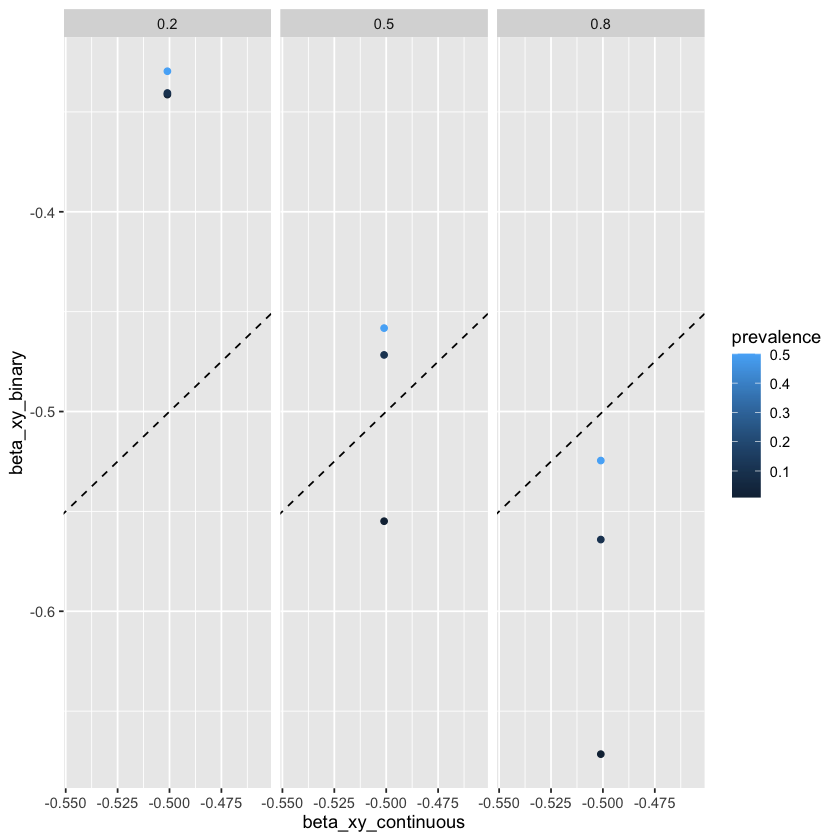

In [ ]:
param <- expand.grid(
    varexp = c(0.2, 0.5, 0.8),
    prevalence = c(0.01, 0.1, 0.5)
)

binary_res <- lapply(1:nrow(param), \(i) {
    varexp <- param[i,]$varexp
    prevalence <- param[i,]$prevalence
    dat$cc2 <- generate_binary_outcome2(dat$y, varexp = varexp, prevalence = prevalence)
    res_continuous <- continuous_2sls(dat$x, dat$y, dat$prs_explained)
    res_binary <- binary_2sls(dat$x, dat$cc2, dat$prs_explained)
    tibble(
        varexp = varexp,
        prevalence = prevalence,
        method = c("binary", "continuous"),
        beta_xy = c(res_binary$beta_xy, res_continuous$beta_xy),
        se_beta_xy = c(res_binary$se_beta_xy, res_continuous$se_beta_xy)
    )
}) %>% bind_rows()

tidyr::pivot_wider(binary_res, names_from = method, values_from = c(beta_xy, se_beta_xy)) %>%
ggplot(., aes(x=beta_xy_continuous, y = beta_xy_binary)) +
    geom_point(aes(colour=prevalence)) +
    facet_grid(. ~ varexp) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed")

In [ ]:
dat <- sim(b_xy = -0.1, b_uy = -0.2, b_ux = 1, b_prs=1, h2=0.7, r2_env_height=0.15, r2_prs=0.4, n=100000)[[2]]

param <- expand.grid(
    varexp = c(0.2, 0.5, 0.8),
    prevalence = c(0.01, 0.1, 0.5),
    rep = 1:100
)
binary_res <- lapply(1:nrow(param), \(i) {
    varexp <- param[i,]$varexp
    prevalence <- param[i,]$prevalence
    dat$cc2 <- generate_binary_outcome2(dat$y, varexp = varexp, prevalence = prevalence)
    res_continuous <- continuous_2sls(dat$x, dat$y, dat$prs_explained)
    res_binary <- binary_2sls(dat$x, dat$cc2, dat$prs_explained)
    dat$cc <- generate_binary_outcome(dat$y, varexp = varexp, prevalence = prevalence)
    res_binary1 <- binary_2sls(dat$x, dat$cc, dat$prs_explained)
    tibble(
        
        varexp = varexp,
        prevalence = prevalence,
        method = c("binary2", "continuous", "binary1"),
        beta_xy = c(res_binary$beta_xy, res_continuous$beta_xy, res_binary1$beta_xy),
        se_beta_xy = c(res_binary$se_beta_xy, res_continuous$se_beta_xy, res_binary1$se_beta_xy)
    )
}) %>% bind_rows()

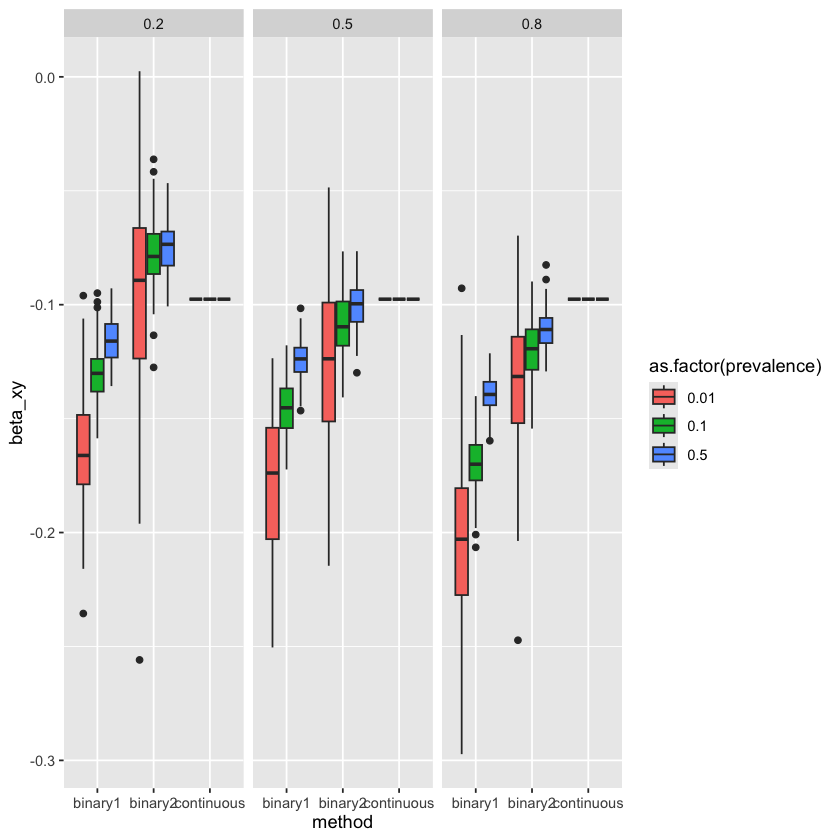

In [ ]:
ggplot(binary_res, aes(x=method, y = beta_xy)) +
    geom_boxplot(aes(fill=as.factor(prevalence))) +
    facet_grid(. ~ varexp) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed")

In [ ]:
simdat <- function(n, prevalence, beta_xl) {
    # 1. Simulate Exposure X (Standard Normal)
    x <- rnorm(n)

    # 2. Simulate Liability L
    # L = beta*X + epsilon, where epsilon is standard normal noise
    epsilon <- rnorm(n)
    l <- beta_xl * x + epsilon

    # 3. Define Threshold T based on prevalence
    threshold <- qnorm(1 - prevalence, mean = 0, sd = sqrt(var(l)))
    y <- as.numeric(l > threshold)

    return(tibble(x = x, l = l, y = y))
}

estimation <- function(dat) {
    # A. Estimate X -> L (Linear Regression - the "Hidden" Truth)
    model_linear <- lm(l ~ x, dat)
    hat_beta_xl <- coef(model_linear)["x"]

    # B. Estimate X -> Y (Logistic GLM - what we usually observe)
    model_logit <- glm(y ~ x, data = dat, family = binomial(link = "logit"))
    hat_beta_logit <- coef(model_logit)["x"]

    # C. Estimate X -> Y (Probit GLM - the LTM-appropriate GLM)
    model_probit <- glm(y ~ x, data = dat, family = binomial(link = "probit"))
    hat_beta_probit <- coef(model_probit)["x"]

    return(tibble(
        method = c("Linear", "Logistic", "Probit", "Logistic (Transformed)"),
        beta_hat = c(hat_beta_xl, hat_beta_logit, hat_beta_probit, hat_beta_logit * (sqrt(3) / pi))
    ))
}

set.seed(42)
simdat(100000, prevalence = 0.1, beta_xl = -0.5) %>% estimation()


method,beta_hat
<chr>,<dbl>
Linear,-0.5028558
Logistic,-0.9754070
Probit,-0.5108572
Logistic (Transformed),-0.5377701


In [ ]:
library(furrr)
plan("multicore", workers=4)
param <- expand.grid(
    n = 100000,
    prevalence = c(0.01, 0.1, 0.5),
    beta_xl = c(-0.5, -0.3, 0)
) %>% furrr::future_pmap(., \(n, prevalence, beta_xl) {
    dat <- simdat(n = n, prevalence = prevalence, beta_xl = beta_xl)
    est <- estimation(dat)
    bind_cols(tibble(n = n, prevalence = prevalence, beta_xl = beta_xl), est)
}) %>% bind_rows()

Warning message:
“UNRELIABLE VALUE: Future (<unnamed-1>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced. To disable this check, use 'seed=NULL', or set option 'future.rng.onMisuse' to "ignore". [future <unnamed-1> (ed502c4b95166bb22746467ddf260d51-1); on ed502c4b95166bb22746467ddf260d51@DT7MTP4F2G<63874>]”
Warning message:
“UNRELIABLE VALUE: Future (<unnamed-2>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced. To disable this check, use 'seed=NULL', or set option 'future.rng.onMisuse' to "ignore". [future <unnamed

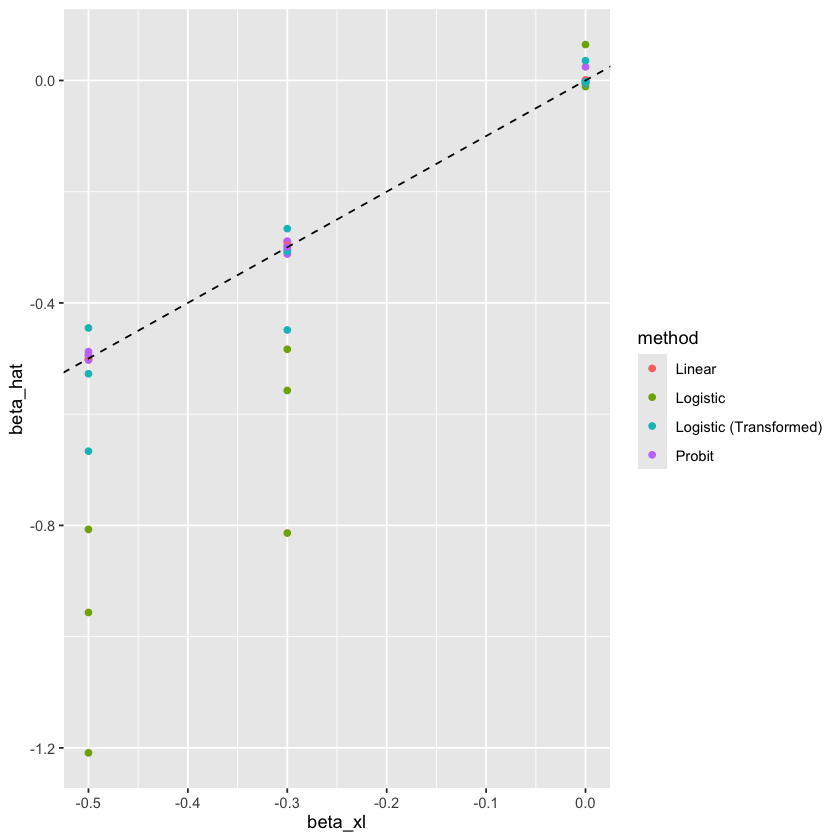

In [ ]:
ggplot(param, aes(x=beta_xl, y=beta_hat, color=method)) +
geom_point() +
geom_abline(slope = 1, intercept = 0, linetype = "dashed")

In [ ]:
generate_binary_outcome3 <- function(liability, varexp=1, prevalence) {
    n <- length(liability)
    threshold <- qnorm(1 - prevalence, mean = 0, sd = sqrt(var(liability)))
    cc <- as.numeric(liability > threshold)
    return(cc)
}

binary_2sls_probit <- function(x, y, prs) {
    mod <- summary(glm(y ~ prs, family=binomial(link = "probit")))
    bgy <- mod$coefficients[2, 1]
    se_bgy <- mod$coefficients[2, 2]

    mod <- summary(lm(x ~ prs))
    bgx <- mod$coefficients[2, 1]
    se_bgx <- mod$coefficients[2, 2]
    beta_xy <- bgy / bgx
    se_beta_xy <- sqrt((se_bgy / bgx)^2 + (bgy * se_bgx / bgx^2)^2)
    return(list(beta_xy = beta_xy, se_beta_xy = se_beta_xy))
}

param <- expand.grid(
    prevalence = c(0.01, 0.1, 0.5),
    b_xy = c(-0.5, -0.3, 0),
    rep = 1:50
)
plan("multicore", workers=8)
binary_res <- future_pmap(param, \(prevalence, rep, b_xy) {
    dat <- sim(b_xy = b_xy, b_uy = -0.2, b_ux = 1, b_prs=1, h2=0.7, r2_env_height=0.15, r2_prs=0.4, n=100000)[[2]]

    dat$cc <- generate_binary_outcome3(dat$y, prevalence = prevalence)
    res_continuous <- continuous_2sls(dat$x, dat$y, dat$prs_explained)
    res_binary <- binary_2sls_probit(dat$x, dat$cc, dat$prs_explained)
    tibble(
        prevalence = prevalence,
        method = c("binary", "continuous"),
        beta_xy = c(res_binary$beta_xy, res_continuous$beta_xy),
        se_beta_xy = c(res_binary$se_beta_xy, res_continuous$se_beta_xy),
        rep = rep,
        b_xy = b_xy
    )
}) %>% bind_rows()
str(binary_res)

Warning message:
“UNRELIABLE VALUE: Future (<unnamed-25>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced. To disable this check, use 'seed=NULL', or set option 'future.rng.onMisuse' to "ignore". [future <unnamed-25> (ed502c4b95166bb22746467ddf260d51-25); on ed502c4b95166bb22746467ddf260d51@DT7MTP4F2G<63874>]”
Warning message:
“UNRELIABLE VALUE: Future (<unnamed-26>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced. To disable this check, use 'seed=NULL', or set option 'future.rng.onMisuse' to "ignore". [future <unn

tibble [900 × 6] (S3: tbl_df/tbl/data.frame)
 $ prevalence: num [1:900] 0.01 0.01 0.1 0.1 0.5 0.5 0.01 0.01 0.1 0.1 ...
 $ method    : chr [1:900] "binary" "continuous" "binary" "continuous" ...
 $ beta_xy   : num [1:900] -0.444 -0.497 -0.465 -0.51 -0.442 ...
 $ se_beta_xy: num [1:900] 0.0238 0.00702 0.01087 0.007 0.00797 ...
 $ rep       : int [1:900] 1 1 1 1 1 1 1 1 1 1 ...
 $ b_xy      : num [1:900] -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.3 -0.3 -0.3 -0.3 ...


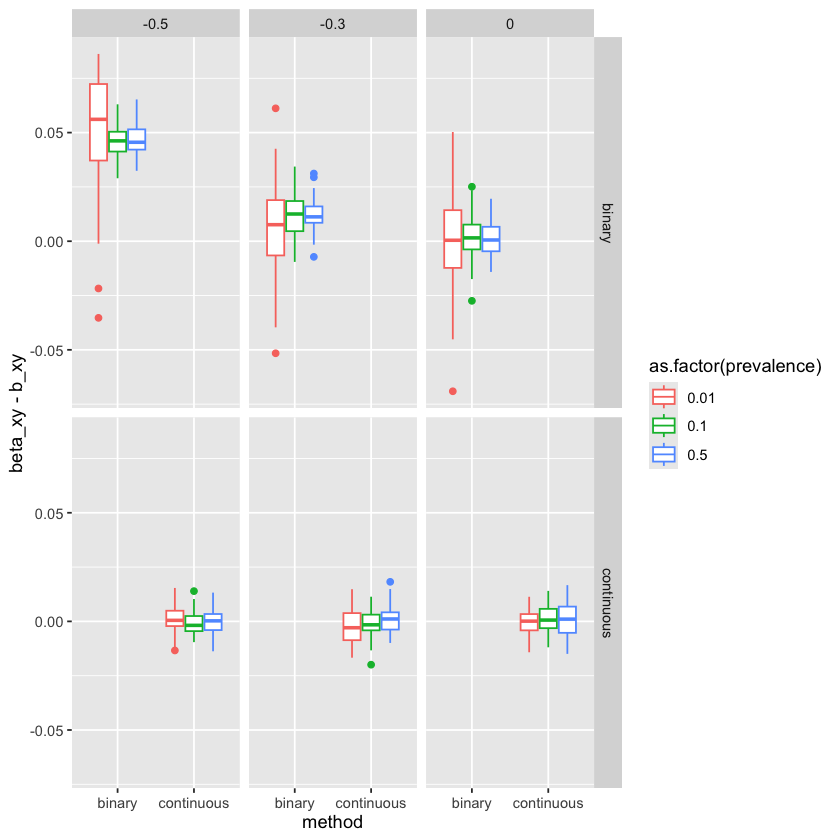

In [ ]:
ggplot(binary_res, aes(x=method, y = beta_xy-b_xy)) +
    geom_boxplot(aes(colour=as.factor(prevalence))) +
    facet_grid(method ~ b_xy)
    

In [ ]:
# Function to estimate beta_cy from height, PRS, and outcome

binary_2sls <- function(x, y, prs, method=c("probit", "logistic", "absolute")[1]) {
    if(method == "probit") {
        mod <- summary(glm(y ~ prs, family=binomial(link = "probit")))
    } else if(method == "logistic") {
        mod <- summary(glm(y ~ prs, family=binomial(link = "logit")))
    } else if(method == "absolute") {
        mod <- summary(lm(y ~ prs))
    }
    bgy <- mod$coefficients[2, 1]
    se_bgy <- mod$coefficients[2, 2]

    mod <- summary(lm(x ~ prs))
    bgx <- mod$coefficients[2, 1]
    se_bgx <- mod$coefficients[2, 2]
    beta_xy <- bgy / bgx
    se_beta_xy <- sqrt((se_bgy / bgx)^2 + (bgy * se_bgx / bgx^2)^2)
    return(list(beta_xy = beta_xy, se_beta_xy = se_beta_xy))
}

estimate_beta_cy2 <- function(height, prs, outcome, var_c = 0.15, h2 = 0.7, n_boot = 1000, binary_method="probit") {
    stopifnot(binary_method %in% c("probit", "logistic", "absolute"))
    
    # Detect if outcome is binary or continuous
    unique_vals <- unique(outcome)
    is_binary <- length(unique_vals) == 2 && all(sort(unique_vals) == c(0, 1))
    
    # Store original outcome for prevalence calculation
    outcome_original <- outcome
    
    # Calculate prevalence if binary
    if (is_binary) {
        prevalence <- mean(outcome)
        # Calculate liability scale threshold transformation factor
        threshold <- qnorm(prevalence)
        liability_scale_factor <- dnorm(threshold)
        cat(sprintf("Binary outcome detected (prevalence = %.3f)\n", prevalence))
        cat(sprintf("Liability scale transformation factor = %.4f\n", liability_scale_factor))
    } else {
        # Standardize continuous outcome
        outcome <- (outcome - mean(outcome)) / sd(outcome)
        cat("Continuous outcome detected - standardized to mean=0, SD=1\n")
        prevalence <- NA
        liability_scale_factor <- 1
    }

    

    # Use instrumental variable regression to estimate causal effect
    if(is_binary) {
        iv_res <- binary_2sls(height, outcome, prs, method = binary_method)
    } else {
        iv_res <- binary_2sls(height, outcome, prs, method = "absolute")
    }
    beta_xy_prs <- iv_res$beta_xy
    se_beta_xy <- iv_res$se_beta_xy
    
    # Calculate R^2 for PRS
    model_prs <- lm(height ~ prs)
    prs_explained <- fitted.values(model_prs)
    r2_prs <- var(prs_explained) / var(height)
    
    # Estimate beta_cy using method 1 (from covariance of height and outcome)
    beta_cy_method1_observed <- (cov(height, outcome) - beta_xy_prs * var(height)) / var_c
    
    # Method 2: Using height residual
    # Get residual height (height not explained by PRS)
    residual_height <- residuals(model_prs)
    
    # Estimate beta_cy using method 2 (from residual height)
    beta_cy_method2_observed <- (cov(residual_height, outcome) - beta_xy_prs_observed * var(residual_height)) / var_c
    
    # Transform to liability scale if binary
    beta_cy_method1 <- beta_cy_method1_observed / liability_scale_factor
    beta_cy_method2 <- beta_cy_method2_observed / liability_scale_factor
    
    # Parametric bootstrap using 2SLS SE for beta_xy
    n <- length(height)
    boot_results <- matrix(NA, n_boot, 2)
    
    for(i in 1:n_boot) {
        # Sample with replacement
        idx <- sample(1:n, n, replace = TRUE)
        h_boot <- height[idx]
        p_boot <- prs[idx]
        y_boot <- outcome[idx]
        
        # Parametrically resample beta_xy from its sampling distribution
        beta_xy_boot <- rnorm(1, mean = beta_xy_prs, sd = se_beta_xy)
        beta_xy_boot <- beta_xy_boot / liability_scale_factor
        
        # Method 1 bootstrap
        boot_observed_1 <- (cov(h_boot, y_boot) - beta_xy_boot_observed * var(h_boot)) / var_c
        boot_results[i, 1] <- boot_observed_1 / liability_scale_factor
        
        # Method 2 bootstrap
        model_prs_boot <- lm(h_boot ~ p_boot)
        res_boot <- residuals(model_prs_boot)
        boot_observed_2 <- (cov(res_boot, y_boot) - beta_xy_boot_observed * var(res_boot)) / var_c
        boot_results[i, 2] <- boot_observed_2 / liability_scale_factor
    }
    
    # Calculate standard errors
    se_method1 <- sd(boot_results[, 1])
    se_method2 <- sd(boot_results[, 2])
    
    # Calculate covariance between the two estimators using GLS
    # cov(β̂_cy,1, β̂_cy,2) ≈ 1/(N·(σ_C²)²) * [var(Y)var(X,X_res) + var(X,Y)var(X_res,Y)]
    cov_x_xres <- cov(height, residual_height)
    cov_x_y <- cov(height, outcome)
    cov_xres_y <- cov(residual_height, outcome)
    var_y <- var(outcome)
    
    # Covariance of the two beta_cy estimates
    cov_estimators <- (1 / (n * var_c^2)) * (var_y * cov_x_xres + cov_x_y * cov_xres_y)
    
    # Build variance-covariance matrix
    var_method1 <- se_method1^2
    var_method2 <- se_method2^2
    Sigma <- matrix(c(var_method1, cov_estimators,
                      cov_estimators, var_method2), nrow = 2)
    
    # GLS weights (inverse of variance-covariance matrix)
    Sigma_inv <- solve(Sigma)
    weights <- Sigma_inv %*% c(1, 1)
    weight_sum <- sum(weights)
    
    # GLS combined estimate
    beta_cy_combined <- (weights[1] * beta_cy_method1 + weights[2] * beta_cy_method2) / weight_sum
    
    # Variance of combined estimate: var(β̂_combined) = 1 / (1' Σ^(-1) 1)
    var_combined <- as.numeric(1 / (t(c(1, 1)) %*% Sigma_inv %*% c(1, 1)))
    se_combined <- sqrt(var_combined)
    
    # Apply GLS weights to bootstrap distributions
    boot_combined <- (weights[1] * boot_results[, 1] + weights[2] * boot_results[, 2]) / weight_sum
    
    # Return results
    return(list(
        beta_xy = beta_xy_prs,
        se_beta_xy = se_beta_xy,
        beta_cy_method1 = beta_cy_method1,
        beta_cy_method2 = beta_cy_method2,
        beta_cy_combined = beta_cy_combined,
        se_method1 = se_method1,
        se_method2 = se_method2,
        se_combined = se_combined,
        cov_estimators = cov_estimators,
        correlation_estimators = cov_estimators / (se_method1 * se_method2),
        weight_method1 = weights[1] / weight_sum,
        weight_method2 = weights[2] / weight_sum,
        r2_prs = r2_prs,
        is_binary = is_binary,
        prevalence = if(is_binary) prevalence else NA,
        outcome_scale = if(is_binary) "liability" else "standardized",
        beta_cy_method1_observed = beta_cy_method1_observed,
        beta_cy_method2_observed = beta_cy_method2_observed,
        boot_distribution_method1 = boot_results[, 1],
        boot_distribution_method2 = boot_results[, 2],
        boot_distribution_combined = boot_combined
    ))
}


## Expected betas for 

In [ ]:
library(dplyr)
sim_dan <- function(n=100000, bgx1=0.1, bgx2=0.2, bx1y=0.3, bex2=0.4, bey=0.5) {
    g <- rbinom(n, 2, 0.4)
    e <- rnorm(n)
    x1 <- bgx1 * g + rnorm(n)
    x2 <- bgx2 * g + bex2 * e + rnorm(n)
    y <- bx1y * x1 + bey * e + rnorm(n)
    return(list(
        dat = tibble(g = g, x1 = x1, x2 = x2, y = y, e = e),
        param = tibble(bgx1 = bgx1, bgx2 = bgx2, bx1y = bx1y, bex2 = bex2, bey = bey)
    ))
}

dat <- sim_dan()

cov(dat$dat$x2, dat$dat$y)


[1] 0.2031455

In [ ]:
dat$param$bgx2 * dat$param$bgx1 * dat$param$bx1y * var(dat$dat$g) + dat$param$bex2 * dat$param$bey * var(dat$dat$e)

[1] 0.2013657